Load the clean data

In [2]:
import pandas as pd

df_clean = pd.read_csv("titanic_clean.csv")

print(df_clean.shape)
df_clean.head()

(889, 14)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


Stratified Split

In [3]:
# Target variable
y = df_clean["survived"]

# Features
X = df_clean.drop("survived", axis=1)

print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nTarget values:")
print(y.value_counts())

X shape: (889, 13)
y shape: (889,)

Target values:
survived
0    549
1    340
Name: count, dtype: int64


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True))

X_train shape: (711, 13)
X_test shape: (178, 13)
y_train shape: (711,)
y_test shape: (178,)

Training target distribution:
survived
0    0.61744
1    0.38256
Name: proportion, dtype: float64

Testing target distribution:
survived
0    0.617978
1    0.382022
Name: proportion, dtype: float64


Stratified Split Justification
A stratified train/test split was used so that the proportion of survived and not-survived passengers remains approximately consistent in both the training and testing datasets. This is important because the target classes are not perfectly balanced.

Preprocessing and Scaling

In [5]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Numeric columns
numeric_features = [
    'pclass',
    'age',
    'sibsp',
    'parch',
    'fare'
]

# Categorical columns
categorical_features = [
    'sex',
    'embarked'
]

# Numeric preprocessing
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical preprocessing
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

# Combine both
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numeric_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


In [6]:
# Fit preprocessing ONLY on training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform test data using the same fitted preprocessing
X_test_processed = preprocessor.transform(X_test)

print("Original X_train shape:", X_train.shape)
print("Original X_test shape:", X_test.shape)

print("\nProcessed X_train shape:", X_train_processed.shape)
print("Processed X_test shape:", X_test_processed.shape)

Original X_train shape: (711, 13)
Original X_test shape: (178, 13)

Processed X_train shape: (711, 10)
Processed X_test shape: (178, 10)


Three Classifiers on same train/test split

1.Logistics Regression

In [7]:
from sklearn.linear_model import LogisticRegression

# Create Logistic Regression model
logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train the model
logistic_model.fit(X_train_processed, y_train)

print("Logistic Regression trained successfully.")

Logistic Regression trained successfully.


2.Decision Tree

In [8]:
from sklearn.tree import DecisionTreeClassifier

decision_tree_model = DecisionTreeClassifier(
    random_state=42
)

decision_tree_model.fit(
    X_train_processed,
    y_train
)

print("Decision Tree trained successfully.")

Decision Tree trained successfully.


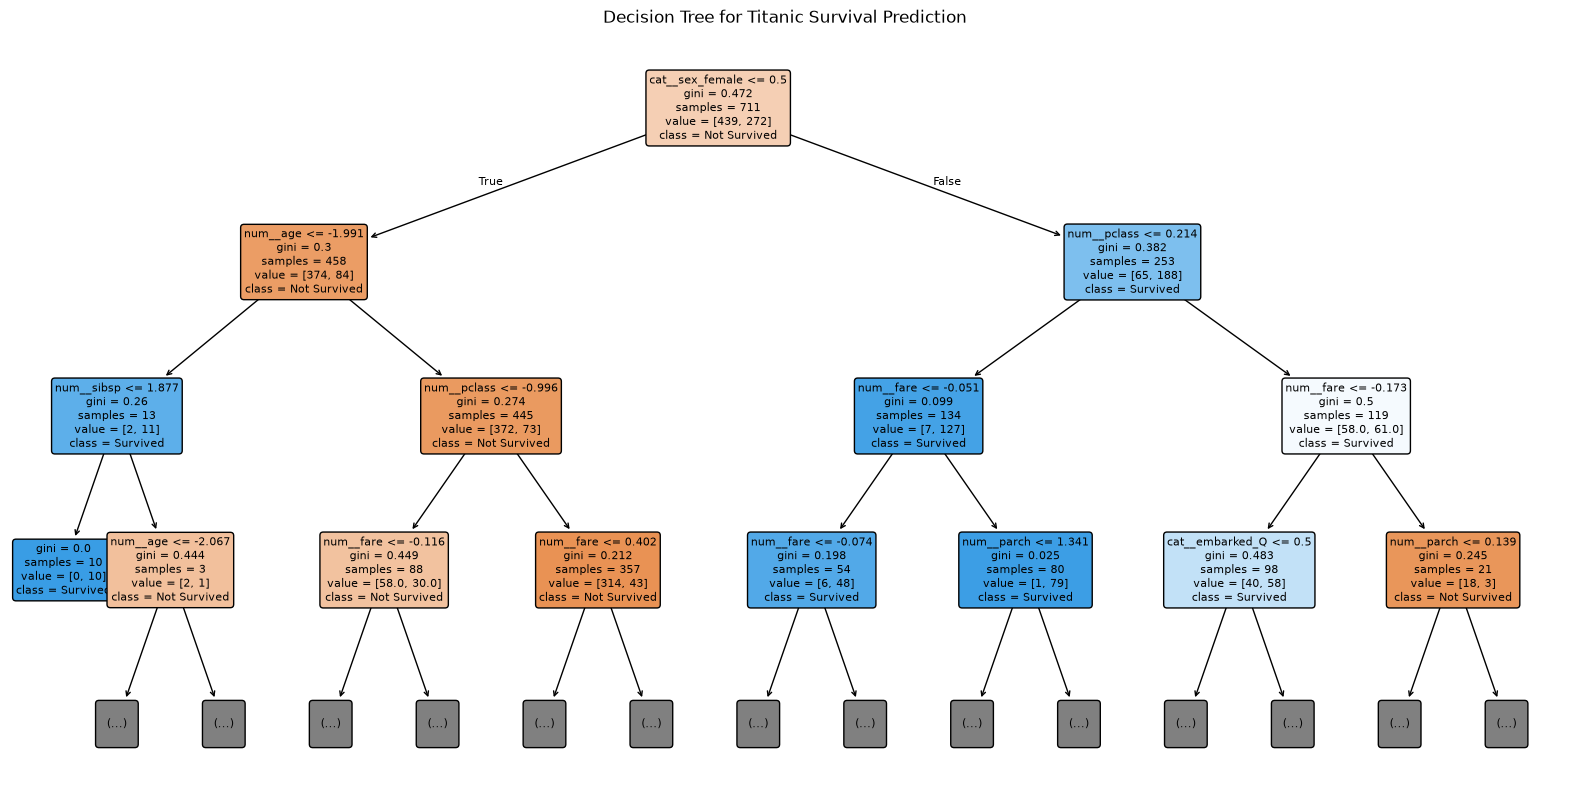

In [9]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Plot the Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    decision_tree_model,
    feature_names=preprocessor.get_feature_names_out(),
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    max_depth=3,
    fontsize=8
)

plt.title("Decision Tree for Titanic Survival Prediction")
plt.show()

3.Random Forest

In [10]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model
random_forest_model.fit(
    X_train_processed,
    y_train
)

print("Random Forest trained successfully.")

Random Forest trained successfully.


Evaluation

In [11]:
# Generate predictions for all three models
y_pred_logistic = logistic_model.predict(X_test_processed)
y_pred_tree = decision_tree_model.predict(X_test_processed)
y_pred_forest = random_forest_model.predict(X_test_processed)

# Probability predictions for ROC-AUC
y_prob_logistic = logistic_model.predict_proba(X_test_processed)[:, 1]
y_prob_tree = decision_tree_model.predict_proba(X_test_processed)[:, 1]
y_prob_forest = random_forest_model.predict_proba(X_test_processed)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [12]:
#metrics values
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# Store the models and predictions
models = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

results = []

for model_name, y_pred in models.items():

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

# Create comparison table
results_df = pd.DataFrame(results)

print("Classification Model Comparison:")
display(results_df.round(4))

Classification Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344
1,Decision Tree,0.7697,0.6901,0.7206,0.7050
2,Random Forest,0.8202,0.7812,0.7353,0.7576


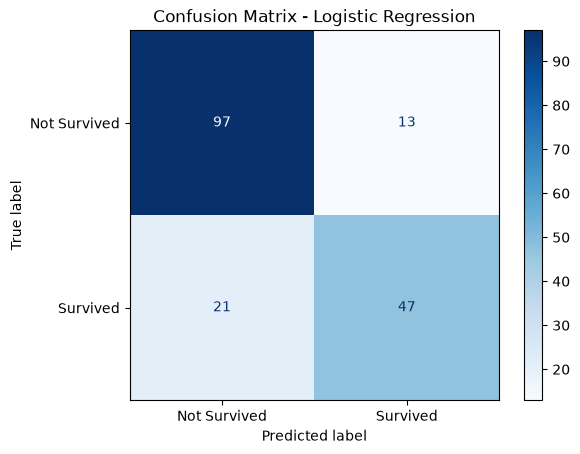

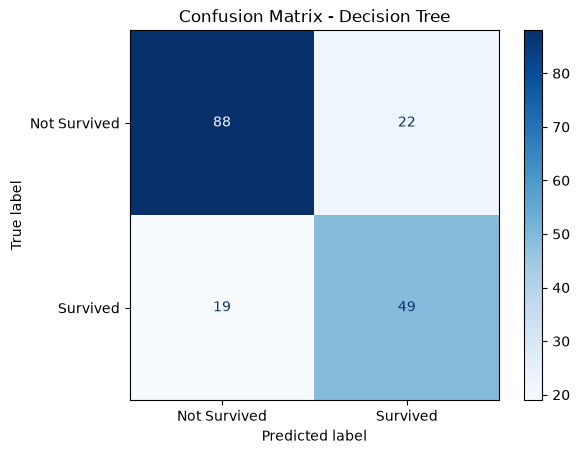

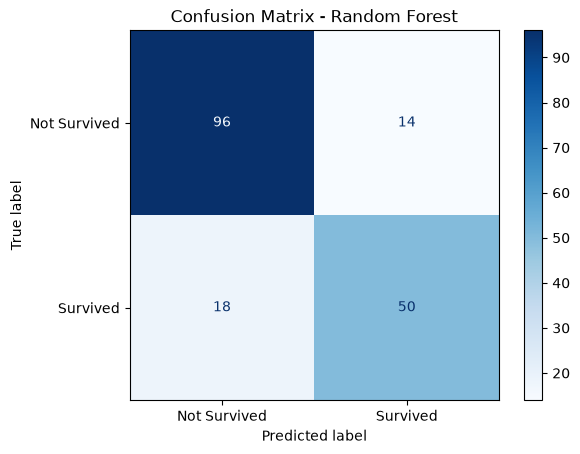

In [13]:
#Confusion matrix display
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Store predictions
predictions = {
    "Logistic Regression": y_pred_logistic,
    "Decision Tree": y_pred_tree,
    "Random Forest": y_pred_forest
}

# Plot confusion matrix for each model
for model_name, y_pred in predictions.items():

    cm_display = ConfusionMatrixDisplay.from_predictions(
        y_test,
        y_pred,
        display_labels=["Not Survived", "Survived"],
        cmap="Blues"
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.show()

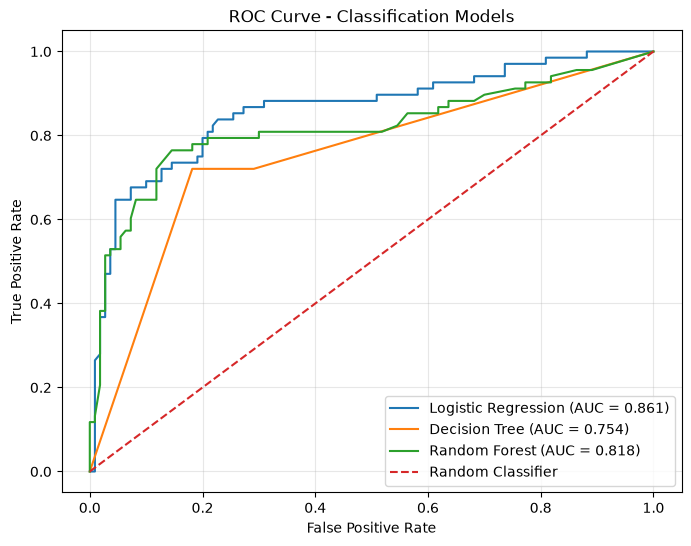

AUC Scores:
Logistic Regression: 0.861
Decision Tree: 0.754
Random Forest: 0.818


In [14]:
#ROC Curve with AUC Scores
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Calculate ROC values
fpr_logistic, tpr_logistic, _ = roc_curve(y_test, y_prob_logistic)
fpr_tree, tpr_tree, _ = roc_curve(y_test, y_prob_tree)
fpr_forest, tpr_forest, _ = roc_curve(y_test, y_prob_forest)

# Calculate AUC
auc_logistic = roc_auc_score(y_test, y_prob_logistic)
auc_tree = roc_auc_score(y_test, y_prob_tree)
auc_forest = roc_auc_score(y_test, y_prob_forest)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    fpr_logistic, tpr_logistic,
    label=f"Logistic Regression (AUC = {auc_logistic:.3f})"
)

plt.plot(
    fpr_tree, tpr_tree,
    label=f"Decision Tree (AUC = {auc_tree:.3f})"
)

plt.plot(
    fpr_forest, tpr_forest,
    label=f"Random Forest (AUC = {auc_forest:.3f})"
)

# Random classifier reference line
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Classification Models")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print("AUC Scores:")
print(f"Logistic Regression: {auc_logistic:.3f}")
print(f"Decision Tree: {auc_tree:.3f}")
print(f"Random Forest: {auc_forest:.3f}")

Imbalance Handling Comparison

1.Baseline model

Previously we train a model which is baseline model.So,we continue with balanced model

2.Balanced model

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Logistic Regression with balanced class weights
logistic_balanced = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=1000
)

# Train only on training data
logistic_balanced.fit(
    X_train_processed,
    y_train
)

# Predict on test data
y_pred_balanced = logistic_balanced.predict(
    X_test_processed
)

print("Balanced Logistic Regression trained successfully.")

#metrics
accuracy_balanced = accuracy_score(
    y_test,
    y_pred_balanced
)

precision_balanced = precision_score(
    y_test,
    y_pred_balanced
)

recall_balanced = recall_score(
    y_test,
    y_pred_balanced
)

f1_balanced = f1_score(
    y_test,
    y_pred_balanced
)

print("Balanced Logistic Regression")
print("Accuracy :", round(accuracy_balanced, 4))
print("Precision:", round(precision_balanced, 4))
print("Recall   :", round(recall_balanced, 4))
print("F1 Score :", round(f1_balanced, 4))

Balanced Logistic Regression trained successfully.
Balanced Logistic Regression
Accuracy : 0.7921
Precision: 0.7183
Recall   : 0.75
F1 Score : 0.7338


3.SMOTE model

In [17]:
from imblearn.over_sampling import SMOTE

# Create SMOTE object
smote = SMOTE(random_state=42)

# Apply SMOTE ONLY to training data
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_processed,
    y_train
)

print("Original training shape:", X_train_processed.shape)
print("After SMOTE shape:", X_train_smote.shape)

print("\nOriginal target distribution:")
print(y_train.value_counts())

print("\nAfter SMOTE target distribution:")
print(y_train_smote.value_counts())

Original training shape: (711, 10)
After SMOTE shape: (878, 10)

Original target distribution:
survived
0    439
1    272
Name: count, dtype: int64

After SMOTE target distribution:
survived
1    439
0    439
Name: count, dtype: int64


In [18]:
# Create Logistic Regression model
logistic_smote = LogisticRegression(
    random_state=42,
    max_iter=1000
)

# Train using SMOTE-balanced training data
logistic_smote.fit(
    X_train_smote,
    y_train_smote
)

# Predict on the original test data
y_pred_smote = logistic_smote.predict(
    X_test_processed
)

print("SMOTE Logistic Regression trained successfully.")

# Calculate SMOTE metrics
accuracy_smote = accuracy_score(y_test, y_pred_smote)
precision_smote = precision_score(y_test, y_pred_smote)
recall_smote = recall_score(y_test, y_pred_smote)
f1_smote = f1_score(y_test, y_pred_smote)

print("SMOTE Logistic Regression")
print("Accuracy :", round(accuracy_smote, 4))
print("Precision:", round(precision_smote, 4))
print("Recall   :", round(recall_smote, 4))
print("F1 Score :", round(f1_smote, 4))

SMOTE Logistic Regression trained successfully.
SMOTE Logistic Regression
Accuracy : 0.7978
Precision: 0.7353
Recall   : 0.7353
F1 Score : 0.7353


In [19]:
# Imbalance Handling Comparison

imbalance_results = pd.DataFrame({
    "Method": [
        "Baseline Logistic Regression",
        "Balanced Logistic Regression",
        "SMOTE Logistic Regression"
    ],
    "Accuracy": [
        accuracy,
        accuracy_balanced,
        accuracy_smote
    ],
    "Precision": [
        precision,
        precision_balanced,
        precision_smote
    ],
    "Recall": [
        recall,
        recall_balanced,
        recall_smote
    ],
    "F1 Score": [
        f1,
        f1_balanced,
        f1_smote
    ]
})

print("Imbalance Handling Comparison:")
display(imbalance_results.round(4))

Imbalance Handling Comparison:


,Method,Accuracy,Precision,Recall,F1 Score
0,Baseline Logistic Regression,0.8202,0.7812,0.7353,0.7576
1,Balanced Logistic Regression,0.7921,0.7183,0.7500,0.7338
2,SMOTE Logistic Regression,0.7978,0.7353,0.7353,0.7353


Imbalance Handling Interpretation:

The baseline Logistic Regression achieved an accuracy of 0.8202 and an F1 score of 0.7576. 
Applying class weighting increased recall slightly to 0.7500, but reduced accuracy, precision, and F1 score. 
SMOTE produced a balanced training set and achieved an accuracy of 0.7978, with precision, recall, and F1 score all at 0.7353. 
Therefore, the imbalance-handling methods changed the precision–recall trade-off, while the baseline model provided the reported overall performance on this test split.

Hyperparameter Tuning

In [20]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV

# Create Random Forest for hyperparameter tuning
rf_tuning = RandomForestClassifier(
    random_state=42,
    oob_score=True,
    bootstrap=True
)

# Hyperparameter grid
param_grid = {
    "n_estimators": [50,100,200],
    "max_depth": [None, 5, 10,15],
    "max_features": ["sqrt", "log2"]
}

# GridSearchCV
grid_search = GridSearchCV(
    estimator=rf_tuning,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Train GridSearchCV
grid_search.fit(X_train_processed, y_train)

print("GridSearchCV completed successfully.")

GridSearchCV completed successfully.


In [21]:
# Get the best Random Forest model
best_rf = grid_search.best_estimator_

# Best hyperparameters found by GridSearchCV
best_rf_param=grid_search.best_params_

print("Best Parameters:")
print(best_rf_param)

print("\nBest Cross-Validation F1 Score:")
print(round(grid_search.best_score_, 4))

#OOB Score
print("\nOOB Score:")
print(round(best_rf.oob_score_, 4))

Best Parameters:
{'max_depth': 15, 'max_features': 'sqrt', 'n_estimators': 200}

Best Cross-Validation F1 Score:
0.7426

OOB Score:
0.8073


Regression (side-task)

In [22]:
# Regression target
y_reg = df_clean["fare"]

# Features: exclude fare because it is the target
X_reg = df_clean.drop(columns=["fare"])

# Train and test split
from sklearn.model_selection import train_test_split

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.20,
    random_state=42
)

print("X_reg_train shape:", X_reg_train.shape)
print("X_reg_test shape:", X_reg_test.shape)
print("y_reg_train shape:", y_reg_train.shape)
print("y_reg_test shape:", y_reg_test.shape)

X_reg_train shape: (711, 13)
X_reg_test shape: (178, 13)
y_reg_train shape: (711,)
y_reg_test shape: (178,)


In [23]:
# Remove the target variable 'fare' from the numeric features
reg_numeric_features = [
    col for col in numeric_features
    if col != "fare"
]

reg_categorical_features = categorical_features.copy()


# Numeric preprocessing
reg_numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Categorical preprocessing
reg_categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# Combine preprocessing
reg_preprocessor = ColumnTransformer(
    transformers=[
        ("num", reg_numeric_transformer, reg_numeric_features),
        ("cat", reg_categorical_transformer, reg_categorical_features)
    ]
)

X_reg_train_processed = reg_preprocessor.fit_transform(X_reg_train)

X_reg_test_processed = reg_preprocessor.transform(X_reg_test)

print("Processed X_reg_train shape:", X_reg_train_processed.shape)
print("Processed X_reg_test shape:", X_reg_test_processed.shape)

Processed X_reg_train shape: (711, 9)
Processed X_reg_test shape: (178, 9)


In [25]:
from sklearn.linear_model import LinearRegression

# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(
    X_reg_train_processed,
    y_reg_train
)

# Predict fare on the test data
y_reg_pred = linear_model.predict(X_reg_test_processed)

print("Linear Regression trained successfully.")



Linear Regression trained successfully.


In [26]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate MAE
mae = mean_absolute_error(y_reg_test, y_reg_pred)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))

# Calculate R²
r2 = r2_score(y_reg_test, y_reg_pred)

# Calculate Adjusted R²
n = len(y_reg_test)                 # number of test observations
p = X_reg_test_processed.shape[1]   # number of predictors

adjusted_r2 = 1 - ((1 - r2) * (n - 1) / (n - p - 1))

# Display results
print("Linear Regression Metrics")
print("-------------------------")
print("MAE        :", round(mae, 4))
print("RMSE       :", round(rmse, 4))
print("R²         :", round(r2, 4))
print("Adjusted R²:", round(adjusted_r2, 4))

Linear Regression Metrics
-------------------------
MAE        : 21.1386
RMSE       : 41.7465
R²         : 0.3468
Adjusted R²: 0.3118


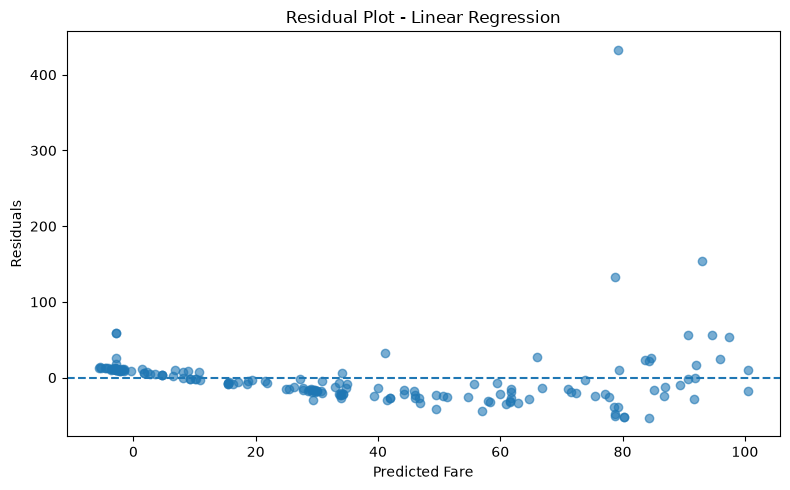

In [27]:
# Calculate residuals
residuals = y_reg_test - y_reg_pred

#residual plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.scatter(y_reg_pred, residuals, alpha=0.6)

# Zero-residual reference line
plt.axhline(y=0, linestyle="--")

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot - Linear Regression")

plt.tight_layout()
plt.show()

Interpretation:
The residuals are not randomly distributed around zero. The spread of residuals increases at higher predicted fare values, and there are several large positive residuals, indicating the presence of heteroscedasticity.
Therefore, the constant-variance assumption of linear regression is not fully satisfied.

Model Comparison Table

In [28]:
# Final Classification Model Comparison

final_classification = results_df.copy()

# Add ROC-AUC values from the variables already calculated
final_classification["ROC-AUC"] = [
    auc_logistic,
    auc_tree,
    auc_forest
]

print("Final Classification Model Comparison:")
display(final_classification.round(4))

Final Classification Model Comparison:


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8090,0.7833,0.6912,0.7344,0.8610
1,Decision Tree,0.7697,0.6901,0.7206,0.7050,0.7541
2,Random Forest,0.8202,0.7812,0.7353,0.7576,0.8179


In [29]:
# Regression Model Metrics

regression_results_df = pd.DataFrame({
    "Model": ["Linear Regression"],
    "MAE": [mae],
    "RMSE": [rmse],
    "R^2": [r2],
    "Adjusted R^2": [adjusted_r2]
})

print("Regression Model Comparison:")
display(regression_results_df.round(4))

Regression Model Comparison:


,Model,MAE,RMSE,R^2,Adjusted R^2
0,Linear Regression,21.1386,41.7465,0.3468,0.3118


Interpertation and Recommendation:

Among the three classification models, Random Forest achieved an accuracy of 0.8202, recall of 0.7353, and F1 score of 0.7576, while Logistic Regression achieved an ROC-AUC of 0.8610. Decision Tree achieved an accuracy of 0.7697 and an F1 score of 0.7050. 
Considering the classification metrics together, I would deploy the Random Forest classifier because it provides the strongest combination of accuracy, recall, and F1 score among the three models evaluated. Logistic Regression, however, produced the highest ROC-AUC of 0.8610.
The Linear Regression model for fare prediction achieved an MAE of 21.1386, RMSE of 41.7465, R² of 0.3468, and adjusted R² of 0.3118.

Complete Pipeline

In [30]:
from sklearn.pipeline import Pipeline
import joblib

# Create complete pipeline
full_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("classifier", best_rf)
])

# Fit the complete pipeline using RAW training data
full_pipeline.fit(X_train, y_train)

print("Complete pipeline trained successfully.")

Complete pipeline trained successfully.


In [33]:
# Save the complete pipeline
model_path = "model_pipeline.joblib"

joblib.dump(full_pipeline, model_path)
print("Pipeline saved successfully.")


# Load the saved pipeline
loaded_pipeline = joblib.load(model_path)
print("Pipeline loaded successfully.")

Pipeline saved successfully.
Pipeline loaded successfully.


In [34]:
# Create one raw passenger record

raw_input = pd.DataFrame({
    "pclass": [3],
    "age": [35],
    "sibsp": [0],
    "parch": [0],
    "fare": [350.0],
    "sex": ["female"],
    "embarked": ["S"]
})

# Make prediction using the loaded pipeline
prediction = loaded_pipeline.predict(raw_input)

print("Prediction:", prediction[0])

if prediction[0] == 1:
    print("Predicted: Survived")
else:
    print("Predicted: Did not survive")

Prediction: 1
Predicted: Survived
